Selected paper: M. Bhagat, A. Sharma and P. Agarwal, "An efficient stacking-based ensemble
technique for early heart attack prediction," 2025.

This notebook contains the full solution:

- Part 1: reproduce the paper's six classifiers (LR, DT, RF, XGB, NB, KNN) and its 5-fold stacking ensemble on the
  1025-row Kaggle heart-disease dataset, then analyse why the results are so high.
- Part 2: a proposed leakage-free, duplicate-aware stacking pipeline with clinically typed preprocessing and
  nested hyperparameter optimisation, evaluated by 10X5-fold repeated CV with significance tests.

## Standard-library, data and plotting imports
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# scikit-learn / XGBoost components: models, preprocessing, validation and metrics
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, brier_score_loss,
                             confusion_matrix, f1_score, matthews_corrcoef, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import (GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold,
                                     train_test_split)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Silence library deprecation noise, widen table display, and define input/output paths
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)
DATA = Path("data") / "heart.csv"

## Dataset
The paper uses the Kaggle Heart Disease Dataset. It has 1025 records, 13 clinical features and a binary target.

In [2]:
# Load the CSV and report size, class balance and missing values
df = pd.read_csv(DATA)
print("Shape:", df.shape)
print("Class balance:", df["target"].value_counts().to_dict())
print("Missing values:", int(df.isna().sum().sum()))

# Data-quality audit: exact duplicate rows and invalid category codes
print("Unique rows:", len(df.drop_duplicates()), "->", len(df) - len(df.drop_duplicates()), "exact duplicates")
print("Invalid codes: ca=4 ->", int((df.ca == 4).sum()), "rows, thal=0 ->", int((df.thal == 0).sum()), "rows")

# Summary statistics of every column
df.describe().T.round(2)

Shape: (1025, 14)
Class balance: {1: 526, 0: 499}
Missing values: 0
Unique rows: 302 -> 723 exact duplicates
Invalid codes: ca=4 -> 18 rows, thal=0 -> 7 rows


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.43,9.07,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.70,0.46,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.94,1.03,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.61,17.52,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.00,51.59,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.53,0.53,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.11,23.01,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.34,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.07,1.18,0.0,0.0,0.8,1.8,6.2


Two data-quality issues:
1. Only 302 of the 1025 rows are unique, while 723 are exact duplicates.
2. ca = 4 and thal = 0 are not valid values. They are the original data's missing values encoded as numbers.

## Shared components
The paper gives no hyperparameters, so default settings are used. Every model is preceded by standardisation.
The stacking meta-classifier is not specified; logistic regression is assumed because it is
the standard, low-variance choice for a meta-learner.

In [3]:
# Load features X and label y
def load(dedup=False):
    d = pd.read_csv(DATA)
    if dedup:
        d = d.drop_duplicates().reset_index(drop=True)
    return d.drop(columns="target"), d["target"]


# The paper's six base classifiers with default settings, each preceded by standardisation
def paper_models(seed):
    models = {
        "LR": LogisticRegression(max_iter=1000),
        "DT": DecisionTreeClassifier(random_state=seed),
        "RF": RandomForestClassifier(random_state=seed),
        "XGB": XGBClassifier(random_state=seed, eval_metric="logloss"),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(),
    }
    return {k: make_pipeline(StandardScaler(), m) for k, m in models.items()}


# The paper's 5-fold stacking ensemble: out-of-fold base predictions feed a logistic-regression meta-learner
def paper_stacking(seed):
    return StackingClassifier(list(paper_models(seed).items()),
                              final_estimator=LogisticRegression(max_iter=1000), cv=5)


# Compute every evaluation metric from true labels and predicted probabilities (0.5 threshold)
def scores(y, prob, thr=0.5):
    pred = (prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {"Accuracy": accuracy_score(y, pred), "Precision": precision_score(y, pred, zero_division=0),
            "Recall": recall_score(y, pred), "F1": f1_score(y, pred), "AUC": roc_auc_score(y, prob),
            "Specificity": tn / (tn + fp), "MCC": matthews_corrcoef(y, pred), "Brier": brier_score_loss(y, prob)}

## Part 1: Reproducing the published results

Protocol as per the paper: standardise, then an 80/20 random hold-out split (205 test rows, which matches the
paper's confusion matrices), six base classifiers, then 5-fold stacking. The paper does not report its random seed,
so seed 42 is used, and we later check how sensitive the results are to that choice.

In [4]:
# Split seed (not reported in the paper) and the paper's published results (Table 11) for comparison
SEED = 42
PAPER = pd.DataFrame(
    {"Accuracy": [.8439, .9268, .9268, .9073, .8439, .8585, .9853],
     "Precision": [.8196, .9702, .9130, .9174, .8250, .8648, 1.0],
     "F1": [.8620, .9289, .9333, .9132, .8608, .8687, .9861],
     "Recall": [.9090, .8909, .9545, .9090, .9000, .8727, .9727],
     "AUC": [.9204, .9702, .9734, .9830, .9185, .9304, .9880]},
    index=["LR", "DT", "RF", "XGB", "NB", "KNN", "Stacking"])


# One run of the paper's protocol: 80/20 split, fit all models on train, score them on test
def run_part1(seed):
    X, y = load()
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)
    models = {**paper_models(seed), "Stacking": paper_stacking(seed)}
    fitted = {n: clone(m).fit(Xtr, ytr) for n, m in models.items()}
    res = pd.DataFrame({n: scores(yte, m.predict_proba(Xte)[:, 1]) for n, m in fitted.items()}).T
    return res, fitted, (Xtr, Xte, ytr, yte)

## 1.1 Single 80/20 split: reproduced vs paper

In [5]:
# Run the reproduction on the seed-42 split and save the full metric table
res, fitted, (Xtr, Xte, ytr, yte) = run_part1(SEED)
res.to_csv(RESULTS / "part1_single_split.csv")

# Side-by-side comparison of reproduced vs published metrics
cmp = pd.concat({"Reproduced": res[["Accuracy", "Precision", "Recall", "F1", "AUC"]], "Paper": PAPER[["Accuracy", "Precision", "Recall", "F1", "AUC"]]}, axis=1)
cmp.round(4)

Reproduced                                      Paper                                  
           Accuracy Precision  Recall      F1     AUC Accuracy Precision  Recall      F1     AUC
LR           0.7951    0.7563  0.8738  0.8108  0.8787   0.8439    0.8196  0.9090  0.8620  0.9204
DT           0.9854    1.0000  0.9709  0.9852  0.9854   0.9268    0.9702  0.8909  0.9289  0.9702
RF           0.9854    1.0000  0.9709  0.9852  1.0000   0.9268    0.9130  0.9545  0.9333  0.9734
XGB          0.9854    1.0000  0.9709  0.9852  0.9894   0.9073    0.9174  0.9090  0.9132  0.9830
NB           0.8000    0.7541  0.8932  0.8178  0.8706   0.8439    0.8250  0.9000  0.8608  0.9185
KNN          0.8341    0.8000  0.8932  0.8440  0.9486   0.8585    0.8648  0.8727  0.8687  0.9304
Stacking     0.9854    1.0000  0.9709  0.9852  1.0000   0.9853    1.0000  0.9727  0.9861  0.9880

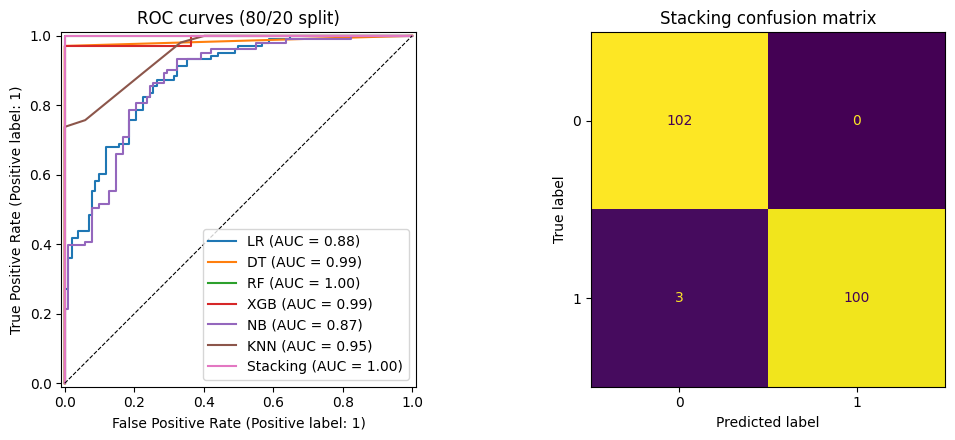

In [6]:
# Left panel: ROC curve of every model on the test set
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for name, m in fitted.items():
    RocCurveDisplay.from_estimator(m, Xte, yte, name=name, ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8); axes[0].set_title("ROC curves (80/20 split)")

# Right panel: confusion matrix of the stacking ensemble, then save the figure
ConfusionMatrixDisplay.from_predictions(yte, fitted["Stacking"].predict(Xte), ax=axes[1], colorbar=False)
axes[1].set_title("Stacking confusion matrix")
fig.tight_layout(); fig.savefig(RESULTS / "part1_roc_cm.png", dpi=150); plt.show()

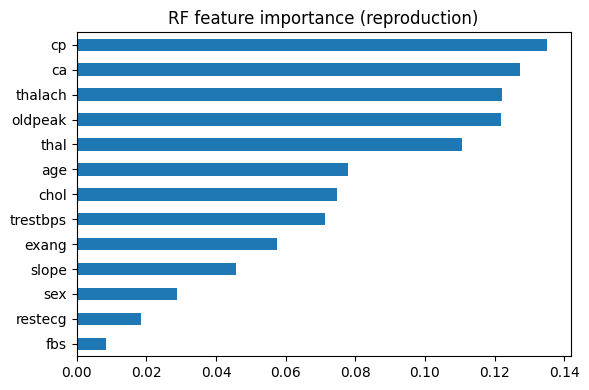

In [7]:
# Impurity-based feature importance from the reproduced RF (compare with Fig. 2 of the paper)
rf = fitted["RF"][-1]
imp = pd.Series(rf.feature_importances_, index=Xtr.columns).sort_values()
ax = imp.plot.barh(figsize=(6, 4), title="RF feature importance (reproduction)")
plt.tight_layout(); plt.savefig(RESULTS / "part1_feature_importance.png", dpi=150); plt.show()

## 1.2 Sensitivity to the random split (30 seeds)

In [8]:
# Repeat the paper's protocol over 30 different random splits
runs = [run_part1(s)[0] for s in range(30)]

# Summarise each metric as mean ± standard deviation across the 30 splits and save
agg = pd.concat(runs).groupby(level=0, sort=False)
split30 = agg.mean().round(4).astype(str) + " ± " + agg.std().round(4).astype(str)
split30.to_csv(RESULTS / "part1_30_splits.csv")
split30[["Accuracy", "Precision", "Recall", "F1", "AUC"]]

,Accuracy,Precision,Recall,F1,AUC
LR,0.8447 ± 0.0225,0.8167 ± 0.0376,0.9006 ± 0.0274,0.8559 ± 0.0232,0.9201 ± 0.0129
DT,0.9959 ± 0.0096,0.994 ± 0.0144,0.998 ± 0.0074,0.996 ± 0.0095,0.9959 ± 0.0096
RF,0.998 ± 0.0064,0.998 ± 0.0075,0.9982 ± 0.007,0.9981 ± 0.0063,0.9999 ± 0.0003
XGB,0.9976 ± 0.0067,0.9962 ± 0.0123,0.9991 ± 0.0048,0.9976 ± 0.0066,0.9999 ± 0.0004
NB,0.8262 ± 0.0243,0.8055 ± 0.034,0.872 ± 0.0286,0.837 ± 0.0261,0.9064 ± 0.016
KNN,0.8507 ± 0.0261,0.8522 ± 0.0443,0.8601 ± 0.0322,0.8552 ± 0.0265,0.9592 ± 0.0102
Stacking,0.9971 ± 0.0089,0.9961 ± 0.0125,0.9982 ± 0.007,0.9971 ± 0.0088,0.9998 ± 0.0008


## 1.3 Leakage

Why do DT, RF, XGB and stacking reach such high metrics? The cell below counts how many test rows also appear verbatim in the training set and scores the models separately on those seen rows and on the genuinely unseen rows.

In [9]:
# Flag test rows that have an identical copy in the training set
key = lambda d: d.astype(str).agg(",".join, axis=1)
seen = key(Xte).isin(set(key(Xtr))).to_numpy()
print(f"Test rows with an exact duplicate in training: {seen.sum()}/{len(seen)} ({seen.mean():.1%})")

# Accuracy of each model on "seen" (duplicated) vs genuinely unseen test rows
pd.DataFrame({n: {"acc on seen rows": np.mean(fitted[n].predict(Xte)[seen] == yte[seen]),
                  f"acc on unseen rows (n={(~seen).sum()})": np.mean(fitted[n].predict(Xte)[~seen] == yte[~seen])}
              for n in fitted}).T.round(4)

Test rows with an exact duplicate in training: 199/205 (97.1%)


,acc on seen rows,acc on unseen rows (n=6)
LR,0.7889,1.0
DT,1.0000,0.5
RF,1.0000,0.5
XGB,1.0000,0.5
NB,0.7940,1.0
KNN,0.8291,1.0
Stacking,1.0000,0.5


Part 1 findings: The paper's headline stacking accuracy (98.53%) is reproduced almost exactly (98.54%). However,
97% of the test patients are also in the training set. The high-capacity models (DT, RF, XGB and the stack) memorise
them, and on the few unseen rows they drop to chance. The published numbers therefore measure memorisation, and not really generalisation to new patients.

## Part 2: Proposed method

Limitations of the paper that this addresses:

- Duplicate-induced train/test leakage.
- A single hold-out split with no variance estimate or statistical test, since this provides a single, noisy performance score that can be heavily influenced by luck of the draw.
- Nominal codes (cp, restecg, slope, ca, thal) treated as ordinal numbers.
- Invalid codes ca=4 and thal=0 used as if they were real values.
- No hyperparameter optimisation.

Proposed pipeline: The six base learners are kept the same as the paper's, so any gain comes from methodology,
not from using a different classifier:

- Duplicate-aware evaluation: De-duplicate to 302 patients, then run repeated stratified 5-fold CV (10 repeats, 50 folds).
- Clinically typed preprocessing, fitted inside each training fold: Invalid codes become NaN and are imputed with the most frequent value. Nominal features are one-hot encoded, continuous features standardised, and binary features passed through.
- Nested hyperparameter optimisation: An inner 5-fold grid search on AUC for each base learner, then stacking with a logistic-regression meta-learner.
- Evaluation: An ablation (preprocessing only vs preprocessing + HPO), the Brier score for calibration, and the Nadeau–Bengio corrected resampled t-test plus the Wilcoxon signed-rank test.

In [10]:
# Outer CV settings and the clinical type of each feature
N_SPLITS, N_REPEATS, SEED = 5, 10, 0
CAT = ["cp", "restecg", "slope", "ca", "thal"]          # nominal -> one-hot
NUM = ["age", "trestbps", "chol", "thalach", "oldpeak"]  # continuous -> standardised
# sex, fbs, exang are binary -> passthrough

# Same six learners as the paper, each with a small hyperparameter grid for the nested search
SEARCH = {
    "LR": (LogisticRegression(max_iter=5000), {"C": [0.01, 0.1, 1, 10]}),
    "DT": (DecisionTreeClassifier(random_state=SEED), {"max_depth": [3, 5, None], "min_samples_leaf": [1, 5, 10]}),
    "RF": (RandomForestClassifier(n_estimators=300, random_state=SEED),
           {"max_depth": [3, 6, None], "min_samples_leaf": [1, 5]}),
    "XGB": (XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=SEED),
            {"max_depth": [2, 4], "learning_rate": [0.03, 0.1]}),
    "NB": (GaussianNB(), {}),
    "KNN": (KNeighborsClassifier(), {"n_neighbors": [5, 11, 21], "weights": ["uniform", "distance"]}),
}


# Replace the invalid codes ca=4 and thal=0 with NaN (they are the original missing values)
def mark_invalid(X):
    X = X.copy()
    X.loc[X["ca"] == 4, "ca"] = np.nan
    X.loc[X["thal"] == 0, "thal"] = np.nan
    return X


# Clinically typed preprocessing: impute + one-hot the nominal features, standardise the continuous ones,
# pass the binary ones through unchanged
def clinical_prep():
    return make_pipeline(FunctionTransformer(mark_invalid), ColumnTransformer(
        [("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                               OneHotEncoder(handle_unknown="ignore", sparse_output=False)), CAT),
         ("num", StandardScaler(), NUM)], remainder="passthrough"))


# 5-fold stratified stacking with a logistic-regression meta-learner
def stack(estimators):
    return StackingClassifier(estimators, final_estimator=LogisticRegression(max_iter=1000),
                              cv=StratifiedKFold(5, shuffle=True, random_state=SEED))


# Proposed model: wrap each learner in the clinical preprocessing, optionally tune it by inner 5-fold
# grid search (AUC) on the training data only, then stack the resulting pipelines
def proposed(Xtr, ytr, tune=True):
    inner = StratifiedKFold(5, shuffle=True, random_state=SEED)
    estimators = []
    for name, (clf, grid) in SEARCH.items():
        pipe = Pipeline([("prep", clinical_prep()), ("clf", clone(clf))])
        if tune and grid:
            pipe = GridSearchCV(pipe, {f"clf__{k}": v for k, v in grid.items()},
                                cv=inner, scoring="roc_auc", n_jobs=-1).fit(Xtr, ytr).best_estimator_
        estimators.append((name, pipe))
    return stack(estimators).fit(Xtr, ytr)


# Significance test that accounts for overlapping training sets in repeated CV
# Nadeau & Bengio (2003) corrected resampled t-test for repeated k-fold CV.
def corrected_ttest(a, b, n_train, n_test):
    d = np.asarray(a) - np.asarray(b)
    t = d.mean() / np.sqrt((1 / len(d) + n_test / n_train) * d.var(ddof=1))
    return t, 2 * stats.t.sf(abs(t), len(d) - 1)

## 2.1 Leakage-free 10X5-fold CV on the 302 unique patients

In [11]:
# Unique patients only, evaluated with 10X5 repeated stratified CV
X, y = load(dedup=True)
cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
rows = []
for fold, (tr, te) in enumerate(cv.split(X, y)):
    # Fit the paper's models, the ablation and the proposed model on this fold's training data
    Xtr2, Xte2, ytr2, yte2 = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
    models = {**{f"Paper {k}": clone(m).fit(Xtr2, ytr2) for k, m in paper_models(SEED).items()},
              "Paper Stacking": paper_stacking(SEED).fit(Xtr2, ytr2),
              "Ablation: clinical prep (no HPO)": proposed(Xtr2, ytr2, tune=False),
              "Proposed (clinical prep + nested HPO)": proposed(Xtr2, ytr2)}

    # Score every model on the same held-out fold
    for name, m in models.items():
        rows.append({"fold": fold, "model": name, **scores(yte2, m.predict_proba(Xte2)[:, 1])})

# Save per-fold scores, then summarise each model as mean ± std over the 50 folds
folds = pd.DataFrame(rows)
folds.to_csv(RESULTS / "part2_per_fold.csv", index=False)
g = folds.drop(columns="fold").groupby("model", sort=False)
summary = g.mean().round(4).astype(str) + " ± " + g.std().round(4).astype(str)
summary.to_csv(RESULTS / "part2_summary.csv")
summary[["Accuracy", "Precision", "Recall", "F1", "AUC", "Brier"]]

,Accuracy,Precision,Recall,F1,AUC,Brier
model,,,,,,
Paper LR,0.8244 ± 0.0481,0.8154 ± 0.0568,0.8808 ± 0.0663,0.8446 ± 0.0434,0.8994 ± 0.0371,0.127 ± 0.0267
Paper DT,0.7516 ± 0.0453,0.775 ± 0.0517,0.7713 ± 0.081,0.77 ± 0.0474,0.7498 ± 0.0454,0.2484 ± 0.0453
Paper RF,0.8237 ± 0.0421,0.8203 ± 0.0499,0.8701 ± 0.0584,0.8427 ± 0.0377,0.902 ± 0.031,0.128 ± 0.0169
Paper XGB,0.797 ± 0.0435,0.8017 ± 0.0502,0.837 ± 0.0677,0.8169 ± 0.0414,0.8812 ± 0.0349,0.1587 ± 0.0323
Paper NB,0.8204 ± 0.0445,0.8268 ± 0.0471,0.8505 ± 0.0708,0.8365 ± 0.0433,0.8938 ± 0.0361,0.1431 ± 0.0329
Paper KNN,0.8131 ± 0.0411,0.8105 ± 0.0459,0.8602 ± 0.0592,0.833 ± 0.0372,0.8766 ± 0.0321,0.1384 ± 0.0207
Paper Stacking,0.8244 ± 0.0464,0.8195 ± 0.0562,0.8743 ± 0.0619,0.8439 ± 0.041,0.9067 ± 0.0293,0.1245 ± 0.0228
Ablation: clinical prep (no HPO),0.8452 ± 0.0445,0.844 ± 0.0559,0.8828 ± 0.0563,0.8611 ± 0.0392,0.9095 ± 0.0325,0.1184 ± 0.0239
Proposed (clinical prep + nested HPO),0.8383 ± 0.043,0.8371 ± 0.0527,0.8773 ± 0.0614,0.8547 ± 0.0384,0.9085 ± 0.0336,0.1213 ± 0.0244


## 2.2 Statistical comparison against the paper's stacking (paired over identical folds)

In [12]:
# Per-fold scores of the paper's stacking, used as the baseline for the paired tests
n_te = len(X) // N_SPLITS
base = folds[folds.model == "Paper Stacking"]

# Compare each proposed variant with the baseline on identical folds (corrected t-test and Wilcoxon)
out = []
for variant in ["Ablation: clinical prep (no HPO)", "Proposed (clinical prep + nested HPO)"]:
    prop = folds[folds.model == variant]
    for metric in ["Accuracy", "F1", "AUC", "Brier"]:
        a, b = prop[metric].to_numpy(), base[metric].to_numpy()
        t, p = corrected_ttest(a, b, len(X) - n_te, n_te)
        out.append({"variant": variant, "metric": metric, "mean diff": a.mean() - b.mean(),
                    "corrected t": t, "corrected p": p, "Wilcoxon p": stats.wilcoxon(a, b).pvalue})

# Collect and save the significance table
sig = pd.DataFrame(out).round(4)
sig.to_csv(RESULTS / "part2_significance.csv", index=False)
sig

,variant,metric,mean diff,corrected t,corrected p,Wilcoxon p
0,Ablation: clinical prep (no HPO),Accuracy,0.0209,1.2375,0.2218,0.0001
1,Ablation: clinical prep (no HPO),F1,0.0172,1.1346,0.2621,0.0003
2,Ablation: clinical prep (no HPO),AUC,0.0028,0.3261,0.7457,0.1729
3,Ablation: clinical prep (no HPO),Brier,-0.0061,-1.1743,0.2459,0.0002
4,Proposed (clinical prep + nested HPO),Accuracy,0.0139,0.8789,0.3838,0.0035
5,Proposed (clinical prep + nested HPO),F1,0.0108,0.7422,0.4615,0.0121
6,Proposed (clinical prep + nested HPO),AUC,0.0018,0.2159,0.8300,0.5025
7,Proposed (clinical prep + nested HPO),Brier,-0.0032,-0.6194,0.5385,0.0607


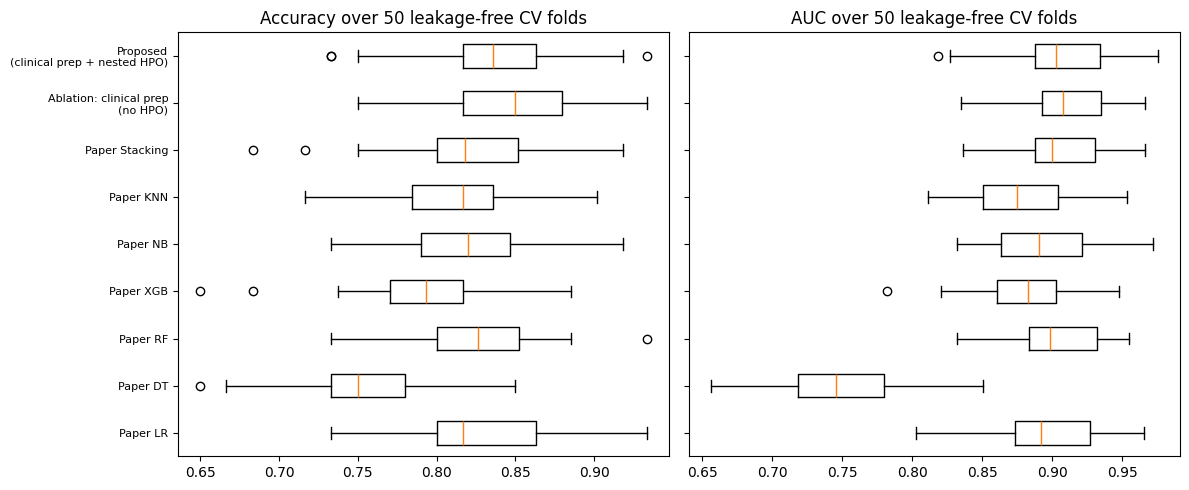

In [13]:
# Boxplots of per-fold accuracy and AUC for every model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric in zip(axes, ["Accuracy", "AUC"]):
    data = [folds[folds.model == m][metric] for m in g.groups]
    try:
        ax.boxplot(data, orientation="horizontal")
    except TypeError:
        ax.boxplot(data, vert=False)
    ax.set_yticks(range(1, len(data) + 1), [m.replace(" (", "\n(") for m in g.groups], fontsize=8)
    ax.set_title(f"{metric} over 50 leakage-free CV folds")
axes[1].set_yticklabels([])
fig.tight_layout(); fig.savefig(RESULTS / "part2_boxplots.png", dpi=150); plt.show()

In [14]:
# Headline table: the paper's reported result vs Part 1 reproduction vs Part 2 leakage-free results
mean = g.mean()
pd.DataFrame({
    "Paper (reported, leaky hold-out)": PAPER.loc["Stacking", ["Accuracy", "F1", "AUC"]],
    "Part 1 reproduction (leaky hold-out)": res.loc["Stacking", ["Accuracy", "F1", "AUC"]],
    "Paper stacking, leakage-free CV": mean.loc["Paper Stacking", ["Accuracy", "F1", "AUC"]],
    "Clinical prep (no HPO), leakage-free CV": mean.loc["Ablation: clinical prep (no HPO)", ["Accuracy", "F1", "AUC"]],
    "Proposed (prep + HPO), leakage-free CV": mean.loc["Proposed (clinical prep + nested HPO)", ["Accuracy", "F1", "AUC"]],
}).T.round(4)

,Accuracy,F1,AUC
"Paper (reported, leaky hold-out)",0.9853,0.9861,0.9880
Part 1 reproduction (leaky hold-out),0.9854,0.9852,1.0000
"Paper stacking, leakage-free CV",0.8244,0.8439,0.9067
"Clinical prep (no HPO), leakage-free CV",0.8452,0.8611,0.9095
"Proposed (prep + HPO), leakage-free CV",0.8383,0.8547,0.9085


## Conclusions:

- Reproduction: The paper's 98.5% stacking accuracy is reproducible, but only because 97% of the test patients also appear in the training data.
- Honest estimate: Evaluated on unique patients with repeated CV, the paper's stacking reaches about 82.4% accuracy and 0.907 AUC.
- Proposed pipeline: Clinically typed preprocessing adds about 2 percentage points of accuracy and gives better calibration (lower Brier score). The gain is consistent across folds (Wilcoxon p < 0.001) but small relative to the variance between folds (the corrected t-test is not significant).
- Nested HPO: It adds no further gain on 302 patients.
- Main contribution: A leakage-free, statistically tested estimate of about 84-85% accuracy, which is what a clinician could realistically expect on new patients.